In [2]:
from pathlib import Path

file = Path("../data/raw/humidity/humidity_2024.nc")

print(file.exists())
print(file.stat().st_size)

True
17825792


In [7]:
from netCDF4 import Dataset

file = "../data/raw/humidity/humidity_2024.nc"

try:
    ds = Dataset(file)
    print(ds)
    print("\nVariables:")
    print(ds.variables.keys())
except Exception as e:
    print(e)

[Errno -101] NetCDF: HDF error: '../data/raw/humidity/humidity_2024.nc'


In [9]:
from pathlib import Path

file = Path("../data/raw/humidity/humidity_2024.nc")

with open(file, "rb") as f:
    print(f.read(16))

b'\x89HDF\r\n\x1a\n\x02\x08\x08\x00\x00\x00\x00\x00'


In [12]:
import xarray as xr
import netCDF4


print("xarray :", xr.__version__)
print("netCDF4 :", netCDF4.__version__)


xarray : 2026.4.0
netCDF4 : 1.7.4


In [16]:
import sys

!{sys.executable} -m pip install h5py h5netcdf netCDF4 xarray

  Using cached h5py-3.16.0-cp313-cp313-win_amd64.whl.metadata (3.1 kB)
  Using cached h5netcdf-1.8.1-py3-none-any.whl.metadata (15 kB)
Using cached h5py-3.16.0-cp313-cp313-win_amd64.whl (3.2 MB)
Using cached h5netcdf-1.8.1-py3-none-any.whl (62 kB)

   ---------------------------------------- 0/2 [h5py]
   ---------------------------------------- 0/2 [h5py]
   ---------------------------------------- 0/2 [h5py]
   ---------------------------------------- 0/2 [h5py]
   ---------------------------------------- 0/2 [h5py]
   ---------------------------------------- 0/2 [h5py]
   ---------------------------------------- 0/2 [h5py]
   -------------------- ------------------- 1/2 [h5netcdf]
   -------------------- ------------------- 1/2 [h5netcdf]
   ---------------------------------------- 2/2 [h5netcdf]



In [17]:
import h5py
import netCDF4
import xarray

print("Everything installed successfully!")

Everything installed successfully!


In [20]:
import xarray as xr

ds = xr.open_dataset("../data/raw/humidity/test.nc")
print(ds)

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01T12:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-26T14:17 GRIB to CDM+CF via cfgrib-0.9.1...


In [21]:
import xarray as xr

ds = xr.open_dataset("../data/raw/humidity/test.nc")

ds

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01T12:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-26T14:17 GRIB to CDM+CF via cfgrib-0.9.1...

In [22]:
print(ds)

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01T12:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-26T14:17 GRIB to CDM+CF via cfgrib-0.9.1...


In [23]:
ds["t2m_c"] = ds["t2m"] - 273.15

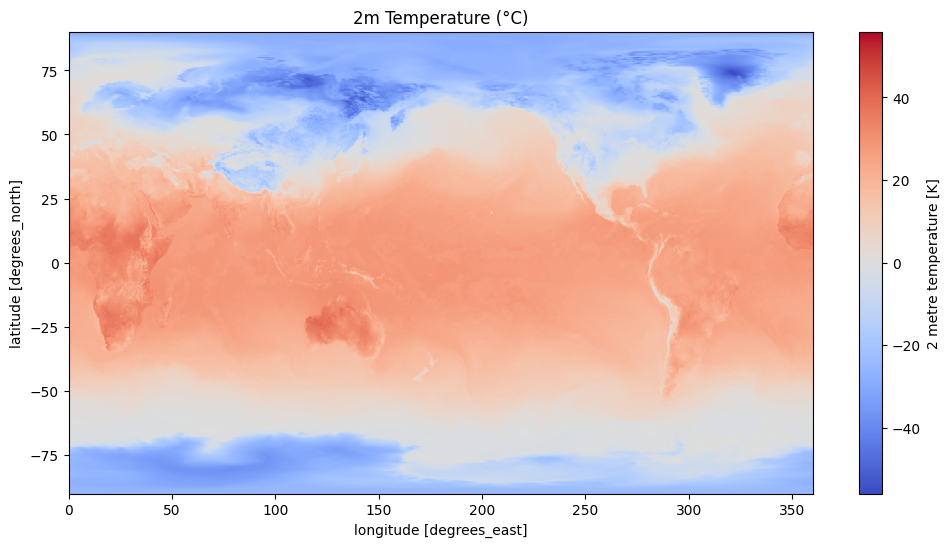

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

ds["t2m_c"].isel(valid_time=0).plot(cmap="coolwarm")

plt.title("2m Temperature (°C)")
plt.show()

In [25]:
df = ds.to_dataframe().reset_index()

df.head()

,valid_time,latitude,longitude,t2m,number,expver,t2m_c
0,2024-01-01 12:00:00,90.0,0.00,245.453018,0,0001,-27.696976
1,2024-01-01 12:00:00,90.0,0.25,245.453018,0,0001,-27.696976
2,2024-01-01 12:00:00,90.0,0.50,245.453018,0,0001,-27.696976
3,2024-01-01 12:00:00,90.0,0.75,245.453018,0,0001,-27.696976
4,2024-01-01 12:00:00,90.0,1.00,245.453018,0,0001,-27.696976


In [26]:
df.isnull().sum()

valid_time    0
latitude      0
longitude     0
t2m           0
number        0
expver        0
t2m_c         0
dtype: int64

In [3]:
import xarray as xr
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

import joblib
import os

In [4]:
ds = xr.open_dataset("../data/raw/humidity/test.nc")

print(ds)

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01T12:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-26T14:17 GRIB to CDM+CF via cfgrib-0.9.1...


In [5]:
df = ds.to_dataframe().reset_index()

df.head()

,valid_time,latitude,longitude,t2m,number,expver
0,2024-01-01 12:00:00,90.0,0.00,245.453018,0,0001
1,2024-01-01 12:00:00,90.0,0.25,245.453018,0,0001
2,2024-01-01 12:00:00,90.0,0.50,245.453018,0,0001
3,2024-01-01 12:00:00,90.0,0.75,245.453018,0,0001
4,2024-01-01 12:00:00,90.0,1.00,245.453018,0,0001


In [6]:
df["year"] = df["valid_time"].dt.year
df["month"] = df["valid_time"].dt.month
df["day"] = df["valid_time"].dt.day
df["hour"] = df["valid_time"].dt.hour
df["dayofyear"] = df["valid_time"].dt.dayofyear

df["latitude2"] = df["latitude"] ** 2
df["longitude2"] = df["longitude"] ** 2

df.head()

,valid_time,latitude,longitude,t2m,number,expver,year,month,day,hour,dayofyear,latitude2,longitude2
0,2024-01-01 12:00:00,90.0,0.00,245.453018,0,0001,2024,1,1,12,1,8100.0,0.0000
1,2024-01-01 12:00:00,90.0,0.25,245.453018,0,0001,2024,1,1,12,1,8100.0,0.0625
2,2024-01-01 12:00:00,90.0,0.50,245.453018,0,0001,2024,1,1,12,1,8100.0,0.2500
3,2024-01-01 12:00:00,90.0,0.75,245.453018,0,0001,2024,1,1,12,1,8100.0,0.5625
4,2024-01-01 12:00:00,90.0,1.00,245.453018,0,0001,2024,1,1,12,1,8100.0,1.0000


In [7]:
features = [
    "latitude",
    "longitude",
    "latitude2",
    "longitude2",
    "year",
    "month",
    "day",
    "hour",
    "dayofyear"
]

X = df[features]

y = df["t2m"]

In [8]:
y

0          245.453018
1          245.453018
2          245.453018
3          245.453018
4          245.453018
              ...    
1038235    248.888565
1038236    248.888565
1038237    248.888565
1038238    248.888565
1038239    248.888565
Name: t2m, Length: 1038240, dtype: float32

In [9]:
X

,latitude,longitude,latitude2,longitude2,year,month,day,hour,dayofyear
0,90.0,0.00,8100.0,0.0000,2024,1,1,12,1
1,90.0,0.25,8100.0,0.0625,2024,1,1,12,1
2,90.0,0.50,8100.0,0.2500,2024,1,1,12,1
3,90.0,0.75,8100.0,0.5625,2024,1,1,12,1
4,90.0,1.00,8100.0,1.0000,2024,1,1,12,1
...,...,...,...,...,...,...,...,...,...
1038235,-90.0,358.75,8100.0,128701.5625,2024,1,1,12,1
1038236,-90.0,359.00,8100.0,128881.0000,2024,1,1,12,1
1038237,-90.0,359.25,8100.0,129060.5625,2024,1,1,12,1
1038238,-90.0,359.50,8100.0,129240.2500,2024,1,1,12,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [11]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [12]:
pred = model.predict(X_test)

In [13]:
pred

array([245.40315, 274.74768, 282.18723, ..., 261.51712, 270.0613 ,
       297.60083], shape=(207648,), dtype=float32)

In [14]:
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

MAE : 0.8086233139038086
RMSE: 1.3429101936751662
R² : 0.9955125451087952


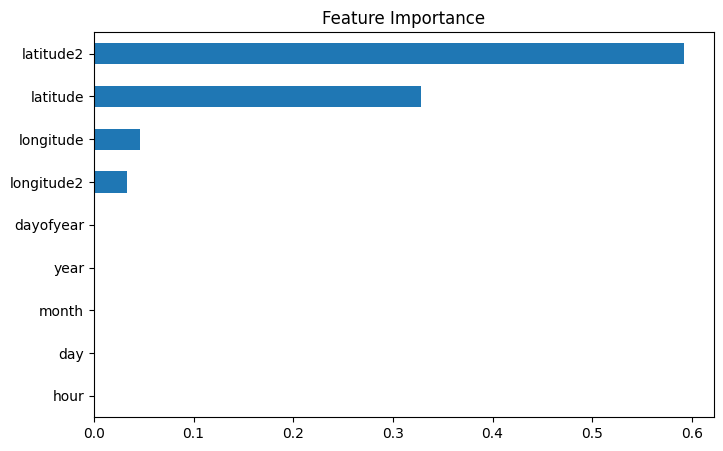

In [15]:
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=features
)

importance.sort_values().plot(kind="barh", figsize=(8,5))

plt.title("Feature Importance")

plt.show()

In [16]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    model,
    "../models/temperature_xgboost.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully


In [17]:
loaded_model = joblib.load("../models/temperature_xgboost.pkl")

print(loaded_model)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)


In [15]:
print(df.head())

           valid_time  latitude  longitude         t2m  number expver  year  \
0 2024-01-01 12:00:00      90.0       0.00  245.453018       0   0001  2024   
1 2024-01-01 12:00:00      90.0       0.25  245.453018       0   0001  2024   
2 2024-01-01 12:00:00      90.0       0.50  245.453018       0   0001  2024   
3 2024-01-01 12:00:00      90.0       0.75  245.453018       0   0001  2024   
4 2024-01-01 12:00:00      90.0       1.00  245.453018       0   0001  2024   

   month  day  hour  dayofyear  latitude2  longitude2  
0      1    1    12          1     8100.0      0.0000  
1      1    1    12          1     8100.0      0.0625  
2      1    1    12          1     8100.0      0.2500  
3      1    1    12          1     8100.0      0.5625  
4      1    1    12          1     8100.0      1.0000  


In [16]:
df["year"] = df["valid_time"].dt.year
df["month"] = df["valid_time"].dt.month
df["day"] = df["valid_time"].dt.day
df["dayofyear"] = df["valid_time"].dt.dayofyear

df = df.rename(columns={
    "latitude": "lat",
    "longitude": "lon"
})

df["lat_lon"] = df["lat"] * df["lon"]

In [10]:
import xarray as xr
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor

In [11]:
ds = xr.open_dataset("../data/raw/humidity/test.nc")

print(ds)

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 8B 2024-01-01T12:00:00
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    number      int64 8B ...
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-06-26T14:17 GRIB to CDM+CF via cfgrib-0.9.1...


In [12]:
df = ds.to_dataframe().reset_index()

print(df.head())

print(df.columns)

           valid_time  latitude  longitude         t2m  number expver
0 2024-01-01 12:00:00      90.0       0.00  245.453018       0   0001
1 2024-01-01 12:00:00      90.0       0.25  245.453018       0   0001
2 2024-01-01 12:00:00      90.0       0.50  245.453018       0   0001
3 2024-01-01 12:00:00      90.0       0.75  245.453018       0   0001
4 2024-01-01 12:00:00      90.0       1.00  245.453018       0   0001
Index(['valid_time', 'latitude', 'longitude', 't2m', 'number', 'expver'], dtype='object')


In [13]:
print("Performing Feature Engineering...")

df["year"] = df["valid_time"].dt.year
df["month"] = df["valid_time"].dt.month
df["day"] = df["valid_time"].dt.day
df["hour"] = df["valid_time"].dt.hour
df["dayofyear"] = df["valid_time"].dt.dayofyear

df["temperature_c"] = df["t2m"] - 273.15

df.head()

Performing Feature Engineering...


,valid_time,latitude,longitude,t2m,number,expver,year,month,day,hour,dayofyear,temperature_c
0,2024-01-01 12:00:00,90.0,0.00,245.453018,0,0001,2024,1,1,12,1,-27.696976
1,2024-01-01 12:00:00,90.0,0.25,245.453018,0,0001,2024,1,1,12,1,-27.696976
2,2024-01-01 12:00:00,90.0,0.50,245.453018,0,0001,2024,1,1,12,1,-27.696976
3,2024-01-01 12:00:00,90.0,0.75,245.453018,0,0001,2024,1,1,12,1,-27.696976
4,2024-01-01 12:00:00,90.0,1.00,245.453018,0,0001,2024,1,1,12,1,-27.696976


In [14]:
features = [
    "latitude",
    "longitude",
    "year",
    "month",
    "day",
    "hour",
    "dayofyear"
]

X = df[features]

y = df["temperature_c"]

In [6]:
from xgboost import XGBRegressor

print("Training XGBoost...")

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    objective="reg:squarederror"
)

model.fit(X_train, y_train)

print("Training Complete")

Training XGBoost...
Training Complete


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [16]:
print("Training XGBoost...")

model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42,
    objective="reg:squarederror"
)

model.fit(X_train, y_train)

print("Training Complete")

Training XGBoost...
Training Complete


In [22]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [26]:
prediction = model.predict(sample)

print(f"Predicted Value: {prediction[0]:.2f}")

Predicted Value: 26.13


In [17]:
prediction = model.predict(X_test)

mae = mean_absolute_error(y_test, prediction)
rmse = np.sqrt(mean_squared_error(y_test, prediction))
r2 = r2_score(y_test, prediction)

print("Model Performance")
print("----------------------")

print("MAE :", mae)
print("RMSE:", rmse)
print("R² :", r2)

Model Performance
----------------------
MAE : 0.8016999363899231
RMSE: 1.3544184328446096
R² : 0.9954352974891663


In [28]:
import joblib

joblib.dump(model, "../models/humidity_xgboost.pkl")

['../models/humidity_xgboost.pkl']

In [23]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    model,
    "../models/humidity_xgboost.pkl"
)

print("Humidity model saved successfully!")

Humidity model saved successfully!


In [29]:
import joblib

humidity_model = joblib.load("../models/humidity_xgboost.pkl")

print("Humidity model loaded successfully!")

Humidity model loaded successfully!


In [20]:
os.makedirs("../models", exist_ok=True)

joblib.dump(
    model,
    "../models/humidity_xgboost.pkl"
)

print("Humidity model saved successfully!")

Humidity model saved successfully!


In [30]:
sample = pd.DataFrame({
    "latitude": [19.0760],
    "longitude": [72.8777],
    "year": [2025],
    "month": [7],
    "day": [10],
    "hour": [12],
    "dayofyear": [191]
})

prediction = humidity_model.predict(sample)

print(f"Predicted Value: {prediction[0]:.2f}")

Predicted Value: 26.13
